In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost prophet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
from google.colab import files
uploaded = files.upload()  # select the downloaded CSV

Saving train.csv.zip to train.csv.zip


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

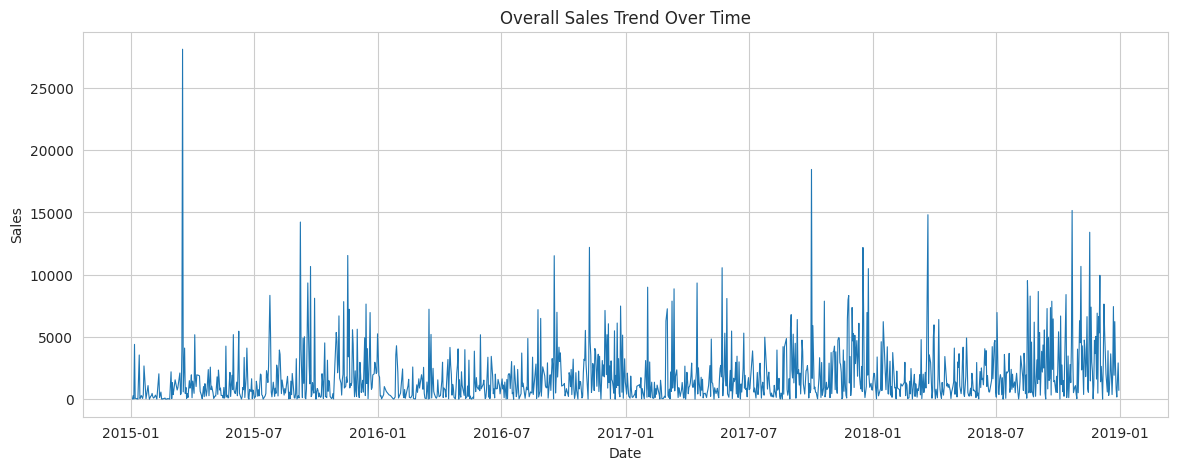

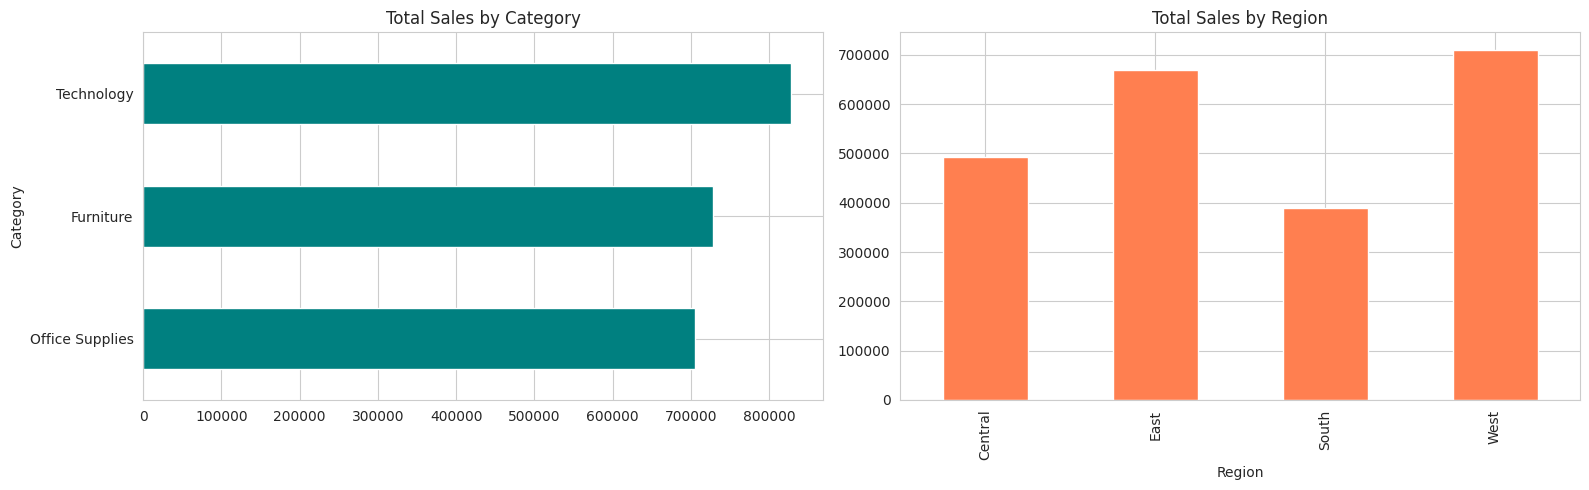

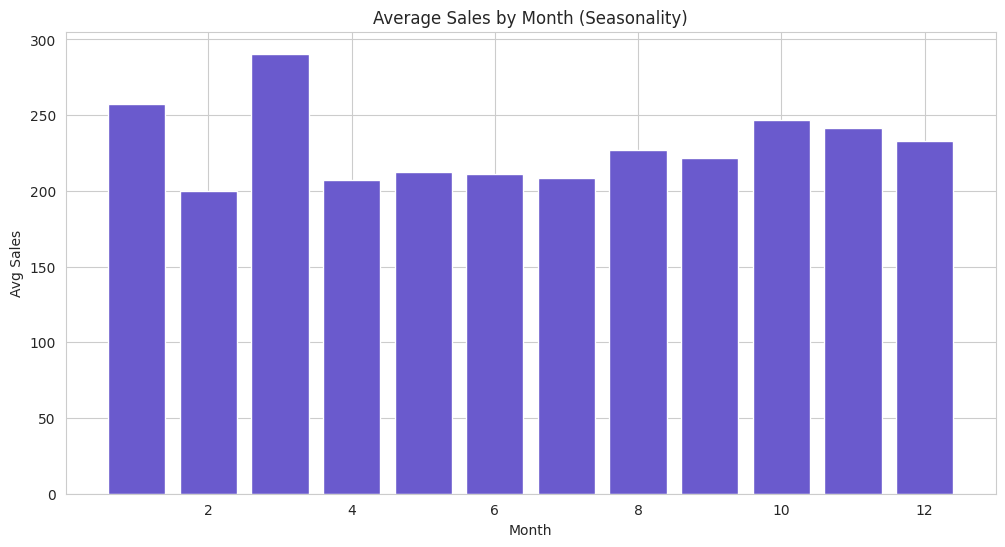

In [9]:
import io

# Assuming 'uploaded' contains a dictionary of {filename: content}
# And the user uploaded a zip file containing a CSV.
uploaded_filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]), compression='zip')

print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nSummary stats:\n", df.describe())
df['Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], linewidth=0.8)
plt.title('Overall Sales Trend Over Time')
plt.xlabel('Date'); plt.ylabel('Sales')
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(16,5))

df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Total Sales by Category')

df.groupby('Region')['Sales'].sum().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Total Sales by Region')
plt.tight_layout()
plt.show()
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()

monthly = df.groupby('Month')['Sales'].mean()
plt.bar(monthly.index, monthly.values, color='slateblue')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month'); plt.ylabel('Avg Sales')
plt.show()

In [10]:
data = daily_sales.copy()
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['Quarter'] = data['Date'].dt.quarter

# Lag features
for lag in [1, 7, 14, 30]:
    data[f'lag_{lag}'] = data['Sales'].shift(lag)

# Rolling averages
data['rolling_mean_7'] = data['Sales'].shift(1).rolling(7).mean()
data['rolling_mean_30'] = data['Sales'].shift(1).rolling(30).mean()

data.dropna(inplace=True)
data.head()

,Date,Sales,Year,Month,Day,DayOfWeek,WeekOfYear,Quarter,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30
30,2015-02-14,576.726,2015,2,14,5,7,1,129.568,97.112,1097.250,16.448,418.550857,593.870300
31,2015-02-15,21.360,2015,2,15,6,7,1,576.726,134.384,426.670,288.060,487.067143,612.546233
32,2015-02-16,9.040,2015,2,16,0,8,1,21.360,330.512,3.928,19.536,470.920857,603.656233
33,2015-02-17,54.208,2015,2,17,1,8,1,9.040,180.320,240.500,4407.100,424.996286,603.306367
34,2015-02-18,37.784,2015,2,18,2,8,1,54.208,14.560,290.666,87.158,406.980286,458.209967


In [11]:
from sklearn.model_selection import train_test_split

feature_cols = ['Year','Month','Day','DayOfWeek','WeekOfYear','Quarter',
                 'lag_1','lag_7','lag_14','lag_30','rolling_mean_7','rolling_mean_30']

X = data[feature_cols]
y = data['Sales']

# Time-based split (no shuffling, since it's a time series)
split_idx = int(len(data) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = data['Date'].iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1020, Test size: 180


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results_df = pd.DataFrame(results).T
print(results_df)

                           MAE         RMSE        R2
Linear Regression  1954.324010  2660.702195  0.011552
Random Forest      1998.594268  2742.826661 -0.050408
XGBoost            1986.923648  2859.679020 -0.141816


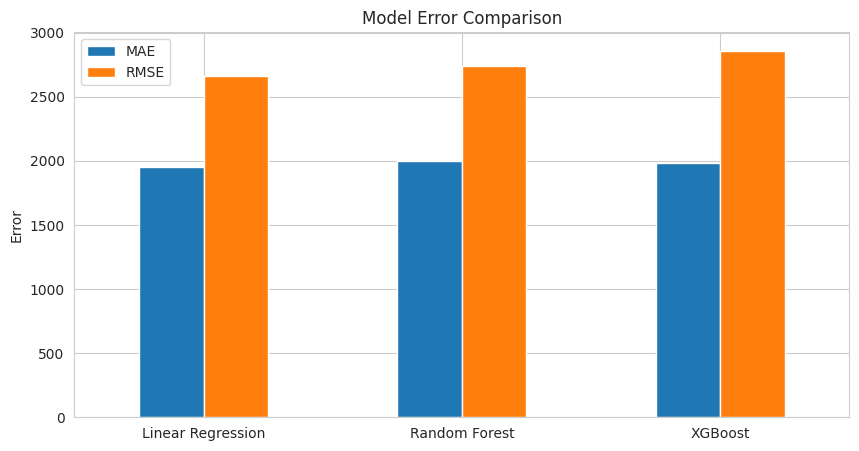


Best model by RMSE: Linear Regression


In [13]:
results_df[['MAE','RMSE']].plot(kind='bar', figsize=(10,5))
plt.title('Model Error Comparison')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

print("\nBest model by RMSE:", results_df['RMSE'].idxmin())

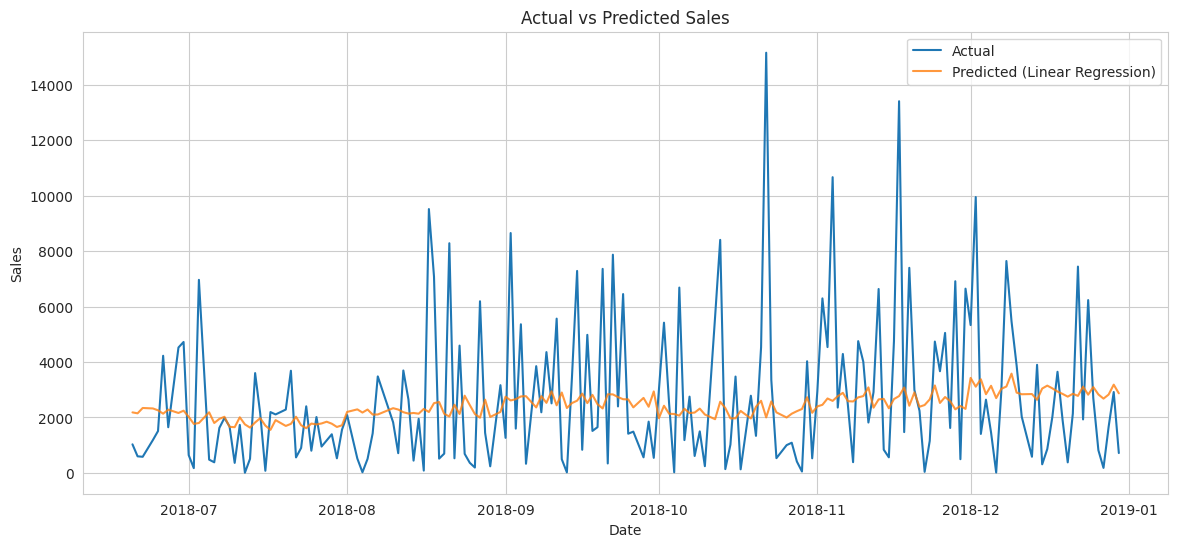

In [14]:
best_model_name = results_df['RMSE'].idxmin()
best_preds = predictions[best_model_name]

plt.figure(figsize=(14,6))
plt.plot(dates_test, y_test.values, label='Actual', linewidth=1.5)
plt.plot(dates_test, best_preds, label=f'Predicted ({best_model_name})', linewidth=1.5, alpha=0.8)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date'); plt.ylabel('Sales')
plt.legend()
plt.show()

In [16]:
best_model = models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()
    importance.plot(kind='barh', figsize=(10,6), color='seagreen')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()

In [17]:
def forecast_future(model, data, feature_cols, days=30):
    last_data = data.copy()
    future_preds = []
    future_dates = []

    current = last_data.iloc[-1:].copy()

    for i in range(days):
        next_date = current['Date'].values[0] + np.timedelta64(1, 'D')

        row = {
            'Year': pd.Timestamp(next_date).year,
            'Month': pd.Timestamp(next_date).month,
            'Day': pd.Timestamp(next_date).day,
            'DayOfWeek': pd.Timestamp(next_date).dayofweek,
            'WeekOfYear': int(pd.Timestamp(next_date).isocalendar().week),
            'Quarter': pd.Timestamp(next_date).quarter,
            'lag_1': last_data['Sales'].iloc[-1],
            'lag_7': last_data['Sales'].iloc[-7],
            'lag_14': last_data['Sales'].iloc[-14],
            'lag_30': last_data['Sales'].iloc[-30],
            'rolling_mean_7': last_data['Sales'].iloc[-7:].mean(),
            'rolling_mean_30': last_data['Sales'].iloc[-30:].mean(),
        }

        X_next = pd.DataFrame([row])[feature_cols]
        pred = model.predict(X_next)[0]

        future_preds.append(pred)
        future_dates.append(next_date)

        new_row = pd.DataFrame({'Date': [next_date], 'Sales': [pred]})
        last_data = pd.concat([last_data, new_row], ignore_index=True)

    return pd.DataFrame({'Date': future_dates, 'Forecasted_Sales': future_preds})

future_forecast = forecast_future(best_model, data[['Date','Sales']], feature_cols, days=30)
print(future_forecast)

         Date  Forecasted_Sales
0  2018-12-31       1762.717870
1  2018-12-31       1624.014901
2  2018-12-31       1539.098914
3  2018-12-31       1419.193348
4  2018-12-31       1555.134545
5  2018-12-31       1734.192609
6  2018-12-31       1477.994108
7  2018-12-31       1645.514208
8  2018-12-31       1628.963900
9  2018-12-31       1590.751582
10 2018-12-31       1571.345788
11 2018-12-31       1600.908461
12 2018-12-31       1624.778800
13 2018-12-31       1596.295524
14 2018-12-31       1598.993268
15 2018-12-31       1594.648187
16 2018-12-31       1599.574015
17 2018-12-31       1616.236052
18 2018-12-31       1612.501615
19 2018-12-31       1602.148976
20 2018-12-31       1608.005603
21 2018-12-31       1673.130152
22 2018-12-31       1643.576670
23 2018-12-31       1691.117260
24 2018-12-31       1677.799234
25 2018-12-31       1662.299032
26 2018-12-31       1650.523815
27 2018-12-31       1658.955580
28 2018-12-31       1677.192680
29 2018-12-31       1658.064605


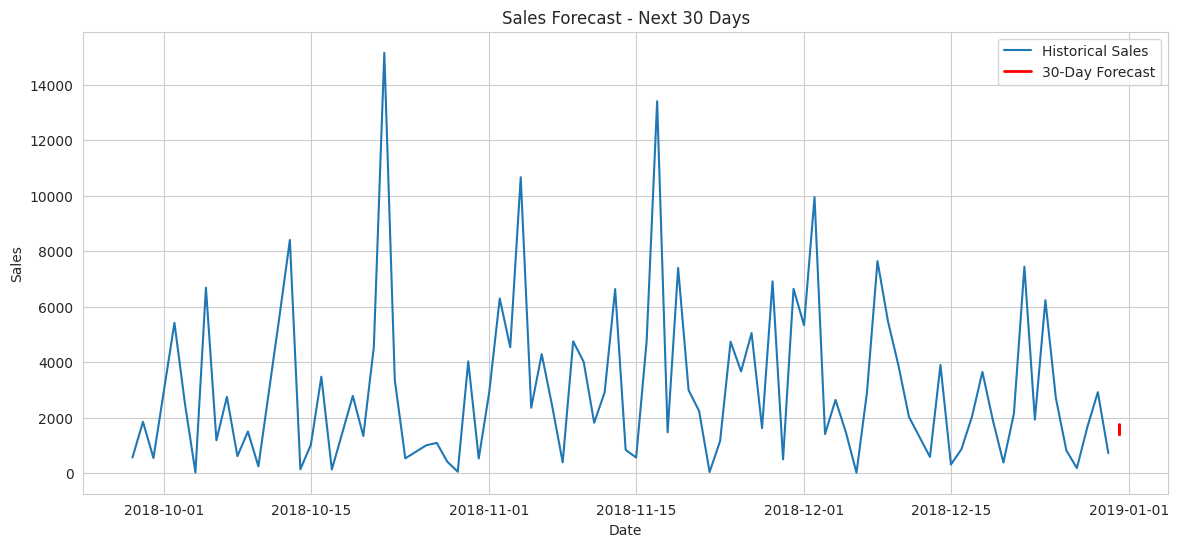

In [18]:
plt.figure(figsize=(14,6))
plt.plot(daily_sales['Date'].iloc[-90:], daily_sales['Sales'].iloc[-90:], label='Historical Sales')
plt.plot(future_forecast['Date'], future_forecast['Forecasted_Sales'], label='30-Day Forecast', color='red', linewidth=2)
plt.title('Sales Forecast - Next 30 Days')
plt.xlabel('Date'); plt.ylabel('Sales')
plt.legend()
plt.show()